In [39]:
import pickle


with open(r'/content/images.p',"rb") as f:
  images = pickle.load(f)

with open(r'/content/labels.p',"rb") as f:
  labels = pickle.load(f)



In [40]:
print(images.shape)
print(labels.shape)


(301,)
(301,)


In [41]:
import numpy as np
labels_list = labels.tolist()
labels_list.remove(".DS")
labels = np.array(labels_list)

In [42]:
set(labels)

{'CHIKU', 'CHINU', 'MAMA'}

In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)


In [44]:
set(labels)

{0, 1, 2}

In [45]:
import numpy as np

In [46]:
n_persons = len(set(labels))
print("Number of person :", n_persons)
label_mapping = le.inverse_transform(np.arange(n_persons))
for  i in range(len(label_mapping)):
  print(i,"-->",label_mapping[i])



Number of person : 3
0 --> CHIKU
1 --> CHINU
2 --> MAMA


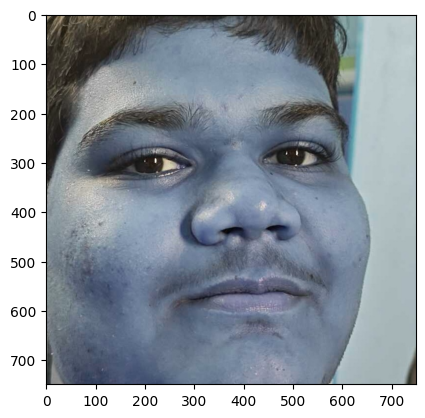

In [47]:
import matplotlib.pyplot as plt
plt.imshow(images[69], cmap = plt.get_cmap("gray"))
plt.show()

In [48]:
import cv2

In [49]:
from tensorflow.keras.utils import to_categorical

In [50]:
labels = to_categorical(labels,3)


In [51]:
categories = labels.shape[1]
print(categories)

3


In [52]:
# def preprocessing(img):
#   img = cv2.equalizeHist(img)
#   img =img.reshape(100,100,1)
#   img = img/255
#   return img

In [53]:
import cv2

# Function to preprocess images
def preprocessing(img):
    # Check if the image is in color (3 channels) and convert to grayscale
    if len(img.shape) == 3 and img.shape[2] == 3:  # Color image (3 channels)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale

    # Ensure the image is in uint8 format
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)

    img = cv2.equalizeHist(img)  # Histogram equalization
    img = cv2.resize(img, (100, 100))  # Resize to 100x100 pixels
    img = img.reshape(100, 100, 1)  # Reshape to include channel dimension
    img = img / 255.0  # Normalize pixel values to [0, 1]
    return img


In [54]:
# Preprocess all images, skipping any that are None
processed_images = []
for img in images:
    if img is not None:  # Only preprocess if the image is not None
        processed_images.append(preprocessing(img))

# Convert the list of processed images to a NumPy array
images = np.array(processed_images)

# Print the shape of the preprocessed images
print("Shape of Input:", images.shape)

Shape of Input: (300, 100, 100, 1)


In [55]:
print("Image shape:", images[0].shape)
print("Image dtype:", images[0].dtype)
print("Image min/max values:", images[0].min(), images[0].max())


Image shape: (100, 100, 1)
Image dtype: float64
Image min/max values: 0.0 1.0


In [56]:
# images = np.array(list(map(preprocessing,images)))
# print("shape of Input: ", images.shape)

In [57]:
from tensorflow.keras.models  import Sequential
from tensorflow.keras.layers  import Dense
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import RMSprop

In [58]:
'''model = Sequential()
model.add(Conv2D(100,(2,2),input_shape=(100,100,1),activation='relu'))
#model.add(Conv2D(64,(5,5),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(50,(2,2),activation='relu'))
#model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(15,activation='relu'))
model.add(Dense(6,activation='softmax'))


#model.add(Dense(categories ,activation='softmax'))

model.compile(RMSprop(learning_rate=0.01),loss='categorical_crossentropy',metrics=['accuracy'])'''


"model = Sequential()\nmodel.add(Conv2D(100,(2,2),input_shape=(100,100,1),activation='relu'))\n#model.add(Conv2D(64,(5,5),activation='relu'))\nmodel.add(MaxPooling2D(pool_size=(2,2)))\n\nmodel.add(Conv2D(50,(2,2),activation='relu'))\n#model.add(Conv2D(32,(3,3),activation='relu'))\nmodel.add(MaxPooling2D(pool_size=(2,2)))\n\nmodel.add(Flatten())\nmodel.add(Dense(15,activation='relu'))\nmodel.add(Dense(6,activation='softmax'))\n\n\n#model.add(Dense(categories ,activation='softmax'))\n\nmodel.compile(RMSprop(learning_rate=0.01),loss='categorical_crossentropy',metrics=['accuracy'])"

In [59]:
model = Sequential()
model.add(Conv2D(15,(3,5),input_shape=(100,100,1),activation='relu'))
#model.add(Conv2D(64,(5,5),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

#model.add(Conv2D(5,(1,1),activation='relu'))
#model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dense(3,activation='softmax'))


#model.add(Dense(categories ,activation='softmax'))

model.compile(RMSprop(learning_rate=0.001),loss='categorical_crossentropy',metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 98, 96, 15)          │             240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 49, 48, 15)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 24, 24, 15)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 8640)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │       4,424,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │           1,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,425,971 (16.88 MB)

 Trainable params: 4,425,971 (16.88 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
print(type(images))
print(type(labels))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [62]:
images = np.array(images)
labels = np.array(labels)

In [63]:
images = images.astype('float32')
labels = labels.astype('float32')

In [64]:
history = model.fit(images,labels,validation_split = 0.1,epochs = 20,  verbose = 1)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.5554 - loss: 1.5922 - val_accuracy: 1.0000 - val_loss: 0.0420
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0315 - val_accuracy: 1.0000 - val_loss: 0.0132
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0109 - val_accuracy: 1.0000 - val_loss: 0.0063
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 8.6820e-04
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 8.6452e-04 - val_accuracy: 1.0000 - val_loss: 6.074

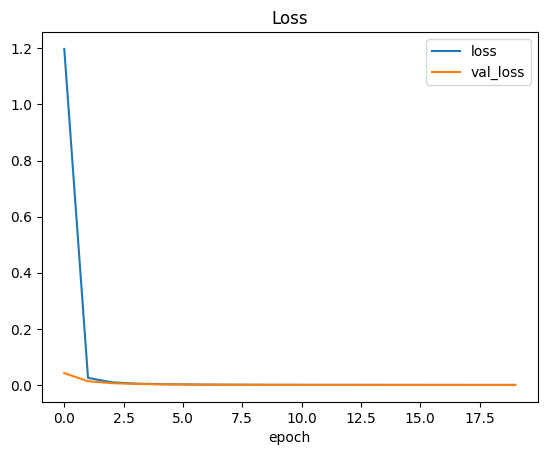

In [65]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss','val_loss'])
plt.title('Loss')
plt.xlabel('epoch')
plt.show()

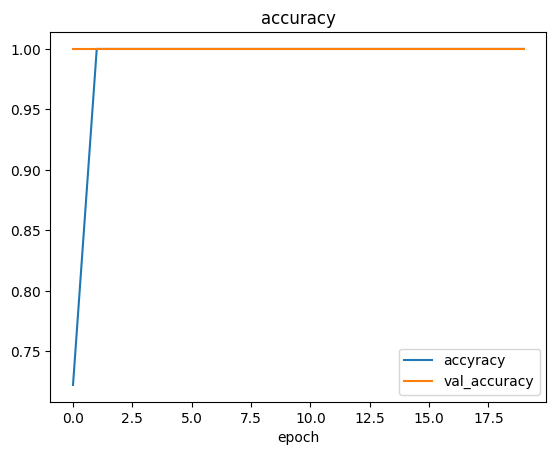

In [66]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accyracy','val_accuracy'])
plt.title('accuracy')
plt.xlabel('epoch')
plt.show()

In [67]:
from google.colab import files
upload = files.upload()

In [68]:
d = list(upload.keys())[0]
print(d)

IndexError: list index out of range

In [ ]:
import cv2
a = np.fromstring(upload[d],np.uint8)
b = cv2.imdecode(a,cv2.IMREAD_COLOR)
print(a)
plt.imshow(b,cmap=plt.get_cmap("gray"))
plt.show()

In [ ]:
 b = cv2.resize(b,(100,100))
 b = cv2.cvtColor(b,cv2.COLOR_BGR2GRAY)
 b = cv2.bitwise_not(b)
 plt.imshow(b,cmap=plt.get_cmap("gray"))
 plt.show()

In [ ]:
b

In [ ]:
b = b/255
b = b.reshape(1, 100, 100, 1)
prediction = model.predict(b)

In [ ]:
print(prediction)

In [ ]:
p = np.argmax(prediction,axis=1)

In [ ]:
p

In [ ]:
model.save('Final_model_10.h5')